# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes



This playbook ranks pseudonymized content items for human review. The model score determines priority, while transparent rules assign one reason code and one suggested action.

| Reason code | Archetype | Suggested action |
|---|---|---|
| `STALE_VISIBLE` | At least 500 impressions and at least 91 days since update | Review whether the content needs refreshing |
| `CTR_OPPORTUNITY` | Search position 4–20, meaningful visibility, and below-median CTR | Review title, snippet, and search-intent alignment |
| `HIGH_VALUE_RISK` | High observed impressions and a high model score | Investigate the performance change before editing |
| `MODEL_REVIEW` | High model score without one dominant rule explanation | Conduct manual diagnosis |
| `MONITOR_ONLY` | Lower-ranked item | Monitor; no immediate action |

When several conditions apply, the first applicable reason in the table is retained so every row has exactly one reason code.

### Decay/refresh insight

In the starter data, pages at least 91 days since their recorded update showed a slightly higher observed decline rate than pages updated within 90 days. This supports using staleness as a review signal, but it does not show that refreshing a page will cause improvement.

The value proxy is observed impressions, not estimated revenue. The score prioritizes investigation; it is not a measure of causal impact or guaranteed business value.

In [1]:
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display


# ------------------------------------------------------------
# Locate the project and anonymized starter dataset.
# ------------------------------------------------------------
if Path("data/raw/content_refresh_anonymized.csv").exists():
    PROJECT_ROOT = Path(".")
else:
    PROJECT_ROOT = Path("/content/flyrank-ml-internship-starter")

    if not PROJECT_ROOT.exists():
        subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/flyrank-bih/"
                "flyrank-ml-internship-starter.git",
                str(PROJECT_ROOT)
            ],
            check=True
        )

DATA_PATH = PROJECT_ROOT / "data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("One row per content item:", df["content_id"].is_unique)


# ------------------------------------------------------------
# Rebuild the Week-5 feature frame.
# ------------------------------------------------------------
df["is_declining_proxy"] = (
    df["trend_direction"].astype(str).str.lower().eq("down")
).astype(int)

df["avg_position_clean"] = df["avg_position"].replace(0, np.nan)
df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_sessions_90d"] = np.log1p(df["sessions_90d"])

FEATURE_COLS = [
    "log_impressions_90d",
    "log_sessions_90d",
    "ctr",
    "avg_position_clean",
    "content_age_days",
    "days_since_last_update",
    "days_with_impressions"
]

FORBIDDEN_FIELDS = {
    "trend_direction",
    "trend_pct",
    "is_declining_proxy",
    "content_id",
    "client_id"
}

assert FORBIDDEN_FIELDS.isdisjoint(FEATURE_COLS)

X = df[FEATURE_COLS]
y = df["is_declining_proxy"]

model = Pipeline([
    (
        "prepare",
        ColumnTransformer([
            (
                "numeric",
                Pipeline([
                    (
                        "impute",
                        SimpleImputer(
                            strategy="median",
                            add_indicator=True
                        )
                    ),
                    ("scale", StandardScaler())
                ]),
                FEATURE_COLS
            )
        ], remainder="drop")
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

# Week 6 tested the method on held-out clients.
# Fit on all available rows here only to produce the final review queue.
model.fit(X, y)
df["model_priority_score"] = model.predict_proba(X)[:, 1]


# ------------------------------------------------------------
# Transparent action rules.
# ------------------------------------------------------------
high_score_cutoff = df["model_priority_score"].quantile(0.75)
high_volume_cutoff = df["impressions_90d"].quantile(0.75)

ctr_reference_rows = df[
    (df["impressions_90d"] >= 500) &
    (df["avg_position_clean"].between(4, 20))
]

low_ctr_cutoff = ctr_reference_rows["ctr"].median()

high_priority = df["model_priority_score"] >= high_score_cutoff

stale_visible = (
    (df["days_since_last_update"] >= 91) &
    (df["impressions_90d"] >= 500)
)

ctr_opportunity = (
    (df["impressions_90d"] >= 500) &
    (df["avg_position_clean"].between(4, 20)) &
    (df["ctr"] <= low_ctr_cutoff)
)

high_value_risk = (
    (df["impressions_90d"] >= high_volume_cutoff) &
    high_priority
)

conditions = [
    stale_visible & high_priority,
    ctr_opportunity & high_priority,
    high_value_risk,
    high_priority
]

reason_choices = [
    "STALE_VISIBLE",
    "CTR_OPPORTUNITY",
    "HIGH_VALUE_RISK",
    "MODEL_REVIEW"
]

df["reason_code"] = np.select(
    conditions,
    reason_choices,
    default="MONITOR_ONLY"
)

action_map = {
    "STALE_VISIBLE": "REVIEW_FOR_REFRESH",
    "CTR_OPPORTUNITY": "REVIEW_TITLE_AND_SNIPPET",
    "HIGH_VALUE_RISK": "INVESTIGATE_PERFORMANCE",
    "MODEL_REVIEW": "MANUAL_DIAGNOSIS",
    "MONITOR_ONLY": "MONITOR"
}

explanation_map = {
    "STALE_VISIBLE": (
        "Visible page with an older recorded update and a high model score."
    ),
    "CTR_OPPORTUNITY": (
        "Visible ranking position with below-reference CTR and a high score."
    ),
    "HIGH_VALUE_RISK": (
        "High observed search visibility makes investigation potentially valuable."
    ),
    "MODEL_REVIEW": (
        "High model score, but no single transparent rule dominates."
    ),
    "MONITOR_ONLY": (
        "Lower current priority; retain for monitoring."
    )
}

df["action_label"] = df["reason_code"].map(action_map)
df["reason_explanation"] = df["reason_code"].map(explanation_map)

score_percentile = df["model_priority_score"].rank(
    pct=True,
    method="average"
)

df["priority_band"] = np.select(
    [
        score_percentile >= 0.95,
        score_percentile >= 0.80
    ],
    [
        "HIGH",
        "MEDIUM"
    ],
    default="MONITOR"
)

df["value_band"] = np.select(
    [
        df["impressions_90d"] >= high_volume_cutoff,
        df["impressions_90d"] >= df["impressions_90d"].median()
    ],
    [
        "HIGH_VISIBILITY",
        "MEDIUM_VISIBILITY"
    ],
    default="LOW_VISIBILITY"
)


# ------------------------------------------------------------
# Build and rank the queue.
# ------------------------------------------------------------
queue_columns = [
    "content_id",
    "model_priority_score",
    "priority_band",
    "reason_code",
    "action_label",
    "reason_explanation",
    "value_band",
    "impressions_90d",
    "ctr",
    "avg_position_clean",
    "content_age_days",
    "days_since_last_update",
    "days_with_impressions"
]

action_queue = (
    df[queue_columns]
    .sort_values(
        ["model_priority_score", "impressions_90d"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

action_queue.insert(0, "rank", np.arange(1, len(action_queue) + 1))


# ------------------------------------------------------------
# Archetype/action map.
# ------------------------------------------------------------
archetype_action_map = pd.DataFrame([
    {
        "reason_code": "STALE_VISIBLE",
        "suggested_action": "Review for refresh",
        "automation": "Human review required"
    },
    {
        "reason_code": "CTR_OPPORTUNITY",
        "suggested_action": "Review title and snippet",
        "automation": "Human review required"
    },
    {
        "reason_code": "HIGH_VALUE_RISK",
        "suggested_action": "Investigate performance",
        "automation": "Human review required"
    },
    {
        "reason_code": "MODEL_REVIEW",
        "suggested_action": "Manual diagnosis",
        "automation": "Human review required"
    },
    {
        "reason_code": "MONITOR_ONLY",
        "suggested_action": "Monitor",
        "automation": "No automatic content change"
    }
])

display(archetype_action_map)


# ------------------------------------------------------------
# Recheck the observed staleness pattern.
# ------------------------------------------------------------
df["staleness_bucket"] = np.where(
    df["days_since_last_update"] >= 91,
    "91+ days",
    "0-90 days"
)

staleness_audit = (
    df.groupby("staleness_bucket", observed=True)
    .agg(
        n=("content_id", "size"),
        decline_rate=("is_declining_proxy", "mean"),
        median_impressions=("impressions_90d", "median")
    )
    .reset_index()
)

staleness_audit["decline_rate"] = (
    staleness_audit["decline_rate"].round(3)
)

print("Observed staleness pattern:")
display(staleness_audit)

print("Top 20 ranked actions:")
display(action_queue.head(20))

Dataset shape: (30000, 44)
One row per content item: True


,reason_code,suggested_action,automation
0,STALE_VISIBLE,Review for refresh,Human review required
1,CTR_OPPORTUNITY,Review title and snippet,Human review required
2,HIGH_VALUE_RISK,Investigate performance,Human review required
3,MODEL_REVIEW,Manual diagnosis,Human review required
4,MONITOR_ONLY,Monitor,No automatic content change


Observed staleness pattern:


,staleness_bucket,n,decline_rate,median_impressions
0,0-90 days,20655,0.512,472.0
1,91+ days,9345,0.608,1621.0


Top 20 ranked actions:


,rank,content_id,model_priority_score,priority_band,reason_code,action_label,reason_explanation,value_band,impressions_90d,ctr,avg_position_clean,content_age_days,days_since_last_update,days_with_impressions
0,1,content_396217b0dc41,0.822780,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1032,0.00,10.8,106,106,87
1,2,content_cbdf5a78dcd0,0.818240,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,HIGH_VISIBILITY,14830,0.02,2.4,126,104,88
2,3,content_db812b31ab45,0.817266,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,LOW_VISIBILITY,595,0.00,5.9,106,106,82
3,4,content_ce611830d125,0.816248,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1409,0.00,6.9,144,104,88
4,5,content_96698a57735c,0.816189,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1030,0.00,15.1,106,106,87
5,6,content_bef9eb4949af,0.814777,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1416,0.07,6.4,106,106,86
6,7,content_c1f7f47a401b,0.813836,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,2731,0.04,2.2,144,104,88
7,8,content_f1cdef315047,0.813342,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1389,0.07,6.2,106,106,85
8,9,content_201dc4530cf2,0.813181,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1486,0.00,6.7,153,104,88
9,10,content_a37ce8ddc090,0.813001,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1039,0.00,2.3,106,106,72


## 2. Intended use and limits

### Intended use

The intended user is a content or SEO analyst. The analyst can use the queue to decide which pseudonymized content items deserve investigation first.

The playbook supports three decisions:

1. Which pages should be reviewed first?
2. What observed signal placed each page in the queue?
3. What investigation should a human perform before changing anything?

### Cost and value

`impressions_90d` is used as a visibility-based value proxy. A high-visibility page may justify earlier review because more observed search exposure is involved. It is not a monetary value estimate.

The queue does not estimate writing cost, engineering cost, conversion value, or expected return. A reviewer must compare the likely value with the actual effort and risk before approving an action.

### Limits

- The data represents one anonymized portfolio and may not generalize to every client.
- The proxy label describes an observed trend; it is not a verified business outcome.
- Trailing feature windows overlap the periods used by the trend proxy, so this version is not a validated future forecast.
- CTR values are percentages multiplied by 100. For example, `0.76` means `0.76%`.
- An average position of zero means unavailable data and is treated as missing.
- The model was validated on one held-out-client split, not on a future production period.
- Refresh-related patterns are observational and do not prove that refreshing causes improvement.
- Model scores are ranking signals and should not be interpreted as calibrated probabilities.

In [2]:
use_summary = pd.DataFrame([
    {
        "item": "Queue rows",
        "value": len(action_queue)
    },
    {
        "item": "High-priority rows",
        "value": int((action_queue["priority_band"] == "HIGH").sum())
    },
    {
        "item": "Medium-priority rows",
        "value": int((action_queue["priority_band"] == "MEDIUM").sum())
    },
    {
        "item": "Monitor rows",
        "value": int((action_queue["priority_band"] == "MONITOR").sum())
    },
    {
        "item": "Highest model score",
        "value": round(action_queue["model_priority_score"].max(), 3)
    },
    {
        "item": "Lowest model score",
        "value": round(action_queue["model_priority_score"].min(), 3)
    }
])

display(use_summary)

print("Reason-code distribution:")
display(
    action_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="n")
)

assert len(action_queue) == len(df)
assert action_queue["content_id"].is_unique
assert action_queue["rank"].is_monotonic_increasing
assert action_queue["reason_code"].notna().all()

print("Queue checks passed.")

,item,value
0,Queue rows,30000.000
1,High-priority rows,1501.000
2,Medium-priority rows,4500.000
3,Monitor rows,23999.000
4,Highest model score,0.823
5,Lowest model score,0.000


Reason-code distribution:


,reason_code,n
0,MONITOR_ONLY,22500
1,MODEL_REVIEW,3069
2,STALE_VISIBLE,2316
3,CTR_OPPORTUNITY,1412
4,HIGH_VALUE_RISK,703


Queue checks passed.


## 3. Human review + the no-go list

### Required human review

Before approving an action, a reviewer must check:

1. Whether the page still serves the correct search intent.
2. Whether the observed change is seasonal or caused by a temporary event.
3. Whether the page has already been edited more recently than the recorded data indicates.
4. Whether another page targets the same topic and could cause cannibalization.
5. Whether traffic quality, conversions, and business priority justify the work.
6. Whether the suggested title, snippet, or content change is factually accurate.
7. Whether legal, brand, editorial, or technical approval is required.
8. Whether missing or unusually small measurements make the recommendation unreliable.

### What must not be automated

The playbook must not automatically:

- publish, rewrite, delete, redirect, or unpublish content;
- change titles, metadata, internal links, or canonical tags;
- treat the model score as proof that a page is declining;
- claim that refreshing content will improve rankings or traffic;
- prioritize solely from the score when important measurements are missing;
- expose client identities, URLs, private queries, or other confidential data;
- make budget, legal, medical, financial, or brand decisions;
- retrain or replace the approved model without validation and human review.

Every recommendation remains a decision-support suggestion until an authorized person reviews and approves it.

In [3]:
# A review sheet for the first 20 actions.
# Blank fields are intentionally left for the human reviewer.

top20_review_sheet = action_queue.head(20)[[
    "rank",
    "content_id",
    "model_priority_score",
    "reason_code",
    "action_label",
    "value_band",
    "impressions_90d",
    "ctr",
    "avg_position_clean",
    "days_since_last_update"
]].copy()

top20_review_sheet["human_decision"] = "PENDING"
top20_review_sheet["review_note"] = ""
top20_review_sheet["approved_action"] = ""
top20_review_sheet["what_would_make_it_wrong"] = (
    "Check intent, seasonality, recent edits, missing data, and business value."
)

display(top20_review_sheet)

print(
    "No action shown above is approved automatically. "
    "Each row begins with human_decision = PENDING."
)

assert (top20_review_sheet["human_decision"] == "PENDING").all()

,rank,content_id,model_priority_score,reason_code,action_label,value_band,impressions_90d,ctr,avg_position_clean,days_since_last_update,human_decision,review_note,approved_action,what_would_make_it_wrong
0,1,content_396217b0dc41,0.822780,STALE_VISIBLE,REVIEW_FOR_REFRESH,MEDIUM_VISIBILITY,1032,0.00,10.8,106,PENDING,,,"Check intent, seasonality, recent edits, missi..."
1,2,content_cbdf5a78dcd0,0.818240,STALE_VISIBLE,REVIEW_FOR_REFRESH,HIGH_VISIBILITY,14830,0.02,2.4,104,PENDING,,,"Check intent, seasonality, recent edits, missi..."
2,3,content_db812b31ab45,0.817266,STALE_VISIBLE,REVIEW_FOR_REFRESH,LOW_VISIBILITY,595,0.00,5.9,106,PENDING,,,"Check intent, seasonality, recent edits, missi..."
3,4,content_ce611830d125,0.816248,STALE_VISIBLE,REVIEW_FOR_REFRESH,MEDIUM_VISIBILITY,1409,0.00,6.9,104,PENDING,,,"Check intent, seasonality, recent edits, missi..."
4,5,content_96698a57735c,0.816189,STALE_VISIBLE,REVIEW_FOR_REFRESH,MEDIUM_VISIBILITY,1030,0.00,15.1,106,PENDING,,,"Check intent, seasonality, recent edits, missi..."
5,6,content_bef9eb4949af,0.814777,STALE_VISIBLE,REVIEW_FOR_REFRESH,MEDIUM_VISIBILITY,1416,0.07,6.4,106,PENDING,,,"Check intent, seasonality, recent edits, missi..."
6,7,content_c1f7f47a401b,0.813836,STALE_VISIBLE,REVIEW_FOR_REFRESH,MEDIUM_VISIBILITY,2731,0.04,2.2,104,PENDING,,,"Check intent, seasonality, recent edits, missi..."
7,8,content_f1cdef315047,0.813342,STALE_VISIBLE,REVIEW_FOR_REFRESH,MEDIUM_VISIBILITY,1389,0.07,6.2,106,PENDING,,,"Check intent, seasonality, recent edits, missi..."
8,9,content_201dc4530cf2,0.813181,STALE_VISIBLE,REVIEW_FOR_REFRESH,MEDIUM_VISIBILITY,1486,0.00,6.7,104,PENDING,,,"Check intent, seasonality, recent edits, missi..."
9,10,content_a37ce8ddc090,0.813001,STALE_VISIBLE,REVIEW_FOR_REFRESH,MEDIUM_VISIBILITY,1039,0.00,2.3,106,PENDING,,,"Check intent, seasonality, recent edits, missi..."


No action shown above is approved automatically. Each row begins with human_decision = PENDING.


## 4. Monitoring / retrain triggers

### Monitoring plan

Monitoring should evaluate both model quality and the data feeding the queue. The Week-6 held-out-client results are the current validation reference:

- Precision@50: 0.840
- Average Precision: 0.618
- ROC AUC: 0.608

These are validation receipts, not permanent production guarantees.

A review or retraining investigation should begin when:

- Precision@50 falls by more than 0.10 from its reference value;
- Average Precision or ROC AUC falls by more than 0.05;
- feature missingness changes by more than 10 percentage points;
- score distributions shift materially;
- new clients or content types are poorly represented in training data;
- the trend-label definition or source tables change;
- reviewers repeatedly reject the same reason code;
- at least one quarter has passed since the last formal review.

A trigger does not automatically authorize retraining. A person must first check data quality, window alignment, leakage, and whether the change is temporary.

In [4]:
validation_reference = {
    "precision_at_50": 0.840,
    "average_precision": 0.618,
    "roc_auc": 0.608,
    "validation_design": "Held-out-client split",
    "client_overlap": 0
}

monitoring_plan = pd.DataFrame([
    {
        "monitor": "Precision@50",
        "reference": "0.840",
        "review_trigger": "Below 0.740",
        "response": "Inspect labels, errors, and queue quality"
    },
    {
        "monitor": "Average Precision",
        "reference": "0.618",
        "review_trigger": "Below 0.568",
        "response": "Check ranking degradation"
    },
    {
        "monitor": "ROC AUC",
        "reference": "0.608",
        "review_trigger": "Below 0.558",
        "response": "Check signal and population drift"
    },
    {
        "monitor": "Feature missingness",
        "reference": "Current run",
        "review_trigger": "Change greater than 10 percentage points",
        "response": "Audit collection and preprocessing"
    },
    {
        "monitor": "Reviewer rejection",
        "reference": "Track by reason code",
        "review_trigger": "Repeated rejection pattern",
        "response": "Revise the affected rule"
    },
    {
        "monitor": "Scheduled review",
        "reference": "Current approved model",
        "review_trigger": "Every quarter",
        "response": "Revalidate before deciding whether to retrain"
    }
])

display(monitoring_plan)

,monitor,reference,review_trigger,response
0,Precision@50,0.840,Below 0.740,"Inspect labels, errors, and queue quality"
1,Average Precision,0.618,Below 0.568,Check ranking degradation
2,ROC AUC,0.608,Below 0.558,Check signal and population drift
3,Feature missingness,Current run,Change greater than 10 percentage points,Audit collection and preprocessing
4,Reviewer rejection,Track by reason code,Repeated rejection pattern,Revise the affected rule
5,Scheduled review,Current approved model,Every quarter,Revalidate before deciding whether to retrain


## 5. Exports for the paper

### Export plan

The notebook exports:

- `work/outputs/content_action_queue.csv` — the full ranked review queue;
- `work/outputs/w07_playbook_metrics.json` — validation references, thresholds, queue counts, and limitations;
- `work/figures/w07_staleness_decline_rate.png` — the observed staleness comparison for possible use in the paper.

The CSV contains pseudonymized content identifiers and no client names, URLs, or private queries. It remains outside Git by design and is regenerated whenever the notebook runs.

The JSON receipt and any reused figure should be committed because they allow the paper’s numbers and claims to be traced back to this notebook.

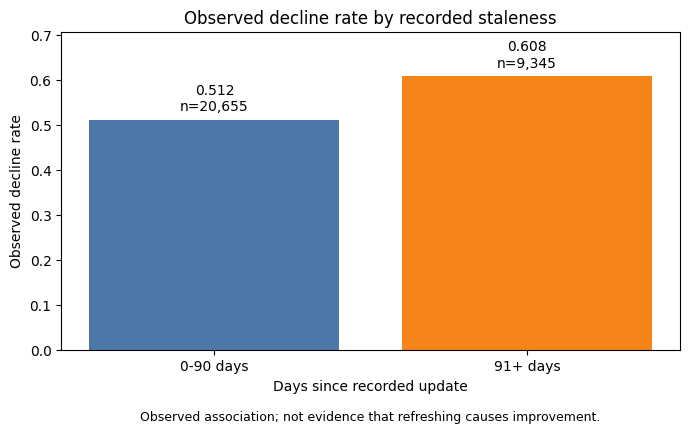

Created: /content/flyrank-ml-internship-starter/work/outputs/content_action_queue.csv (5,056,015 bytes)
Created: /content/flyrank-ml-internship-starter/work/outputs/w07_playbook_metrics.json (1,363 bytes)
Created: /content/flyrank-ml-internship-starter/work/figures/w07_staleness_decline_rate.png (76,123 bytes)

Queue preview:


,rank,content_id,model_priority_score,priority_band,reason_code,action_label,reason_explanation,value_band,impressions_90d,ctr,avg_position_clean,content_age_days,days_since_last_update,days_with_impressions
0,1,content_396217b0dc41,0.822780,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1032,0.00,10.8,106,106,87
1,2,content_cbdf5a78dcd0,0.818240,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,HIGH_VISIBILITY,14830,0.02,2.4,126,104,88
2,3,content_db812b31ab45,0.817266,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,LOW_VISIBILITY,595,0.00,5.9,106,106,82
3,4,content_ce611830d125,0.816248,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1409,0.00,6.9,144,104,88
4,5,content_96698a57735c,0.816189,HIGH,STALE_VISIBLE,REVIEW_FOR_REFRESH,Visible page with an older recorded update and...,MEDIUM_VISIBILITY,1030,0.00,15.1,106,106,87


In [5]:
import json
import matplotlib.pyplot as plt

OUTPUT_DIR = PROJECT_ROOT / "work/outputs"
FIGURE_DIR = PROJECT_ROOT / "work/figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

QUEUE_PATH = OUTPUT_DIR / "content_action_queue.csv"
METRICS_PATH = OUTPUT_DIR / "w07_playbook_metrics.json"
FIGURE_PATH = FIGURE_DIR / "w07_staleness_decline_rate.png"


# ------------------------------------------------------------
# Export the ranked queue.
# ------------------------------------------------------------
action_queue.to_csv(QUEUE_PATH, index=False)


# ------------------------------------------------------------
# Export the metrics and claim receipt.
# ------------------------------------------------------------
action_counts = {
    str(key): int(value)
    for key, value in action_queue["action_label"]
    .value_counts()
    .to_dict()
    .items()
}

reason_counts = {
    str(key): int(value)
    for key, value in action_queue["reason_code"]
    .value_counts()
    .to_dict()
    .items()
}

metrics_receipt = {
    "project": "ML-10 Content Action Playbook",
    "lane": "Refresh / Content Opportunity Scoring",
    "source_rows": int(len(df)),
    "queue_rows": int(len(action_queue)),
    "model": "Logistic Regression",
    "validation_reference": validation_reference,
    "queue_thresholds": {
        "high_score_quantile": 0.75,
        "high_score_cutoff": float(high_score_cutoff),
        "high_volume_quantile": 0.75,
        "high_volume_cutoff": float(high_volume_cutoff),
        "low_ctr_reference": float(low_ctr_cutoff)
    },
    "action_counts": action_counts,
    "reason_counts": reason_counts,
    "limitations": [
        "Scores support ranking and are not calibrated guarantees.",
        "The proxy and trailing feature windows can overlap.",
        "Observed refresh patterns are not causal evidence.",
        "Every proposed content change requires human review."
    ],
    "forbidden_automation": [
        "Automatic publishing",
        "Automatic deletion or redirection",
        "Automatic title or metadata changes",
        "Causal performance claims"
    ]
}

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics_receipt, file, indent=2)


# ------------------------------------------------------------
# Export a paper-ready figure.
# ------------------------------------------------------------
plot_data = staleness_audit.copy()

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    plot_data["staleness_bucket"],
    plot_data["decline_rate"],
    color=["#4C78A8", "#F58518"]
)

ax.set_title("Observed decline rate by recorded staleness")
ax.set_xlabel("Days since recorded update")
ax.set_ylabel("Observed decline rate")
ax.set_ylim(0, max(plot_data["decline_rate"]) + 0.10)

for bar, rate, n in zip(
    bars,
    plot_data["decline_rate"],
    plot_data["n"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{rate:.3f}\nn={n:,}",
        ha="center",
        va="bottom"
    )

ax.text(
    0.5,
    -0.22,
    "Observed association; not evidence that refreshing causes improvement.",
    transform=ax.transAxes,
    ha="center",
    fontsize=9
)

fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=200, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Confirm exports.
# ------------------------------------------------------------
for export_path in [QUEUE_PATH, METRICS_PATH, FIGURE_PATH]:
    print(
        f"Created: {export_path} "
        f"({export_path.stat().st_size:,} bytes)"
    )

print("\nQueue preview:")
display(pd.read_csv(QUEUE_PATH).head())

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.